# 06. Interpretabilidad (SHAP y LIME)

SHAP global (summary plot) y local (waterfall, 2 observaciones: una bien clasificada y una con error alto) para el **mejor modelo** identificado en `05_results_analysis.ipynb`, más la comparación LIME vs. SHAP **específicamente para XGBoost** que pide el curso.

Trabaja desde `results/experiments_master.csv` (mismo patrón que `05_results_analysis.ipynb`), no depende de nada en memoria de notebooks anteriores.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

import numpy as np

from src import config
from src.data_loader import load_processed_dataset, split_features_target
from src.synthetic_data import generate_synthetic_dataset
from src.preprocessing import remove_duplicate_rows
from src.models import MODEL_REGISTRY
from src.experiment_runner import load_master_table
from src import interpretability as ip

np.random.seed(config.RANDOM_STATE)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

try:
    df = load_processed_dataset()
except FileNotFoundError:
    df = generate_synthetic_dataset()
df, _ = remove_duplicate_rows(df)
X, y = split_features_target(df)

table = load_master_table(config.EXPERIMENTS_MASTER_PATH)
if table.empty:
    raise RuntimeError("La tabla maestra está vacía. Correr primero 04_run_experiments.ipynb.")

## Elegir el mejor modelo y ajustar su pipeline

El fold externo usado es el de mejor desempeño (`{metric}_per_fold`, ver columna persistida por `nested_cv.py`); SHAP/LIME se calculan sobre ESE fold de prueba.

In [2]:
metric_for_ranking = config.DEFAULT_SCORING
best_row = table.sort_values(f"{metric_for_ranking}_mean", ascending=False).iloc[0]
best_model = best_row["model"]
best_technique = best_row["technique"]
best_method = best_row["method"]

best_params_per_fold = json.loads(best_row["best_params_per_fold"])
per_fold_metric = json.loads(best_row[f"{metric_for_ranking}_per_fold"])
best_fold_idx = int(np.argmax(per_fold_metric))
best_params = best_params_per_fold[best_fold_idx]

print(f"Mejor modelo: {best_model} | {best_technique} | {best_method} (fold {best_fold_idx})")

spec = MODEL_REGISTRY[best_model]
fitted = ip.fit_explainable_pipeline(
    spec, best_technique, best_params, X, y, best_fold_idx,
    n_outer_folds=int(best_row["n_outer_folds"]),
)
model_step = fitted["pipeline"].named_steps["model"]
print(f"Features post-transformación: {len(fitted['feature_names'])}")

Mejor modelo: decision_tree | none | random_search (fold 2)
Features post-transformación: 25


## SHAP global (summary plot)

Sobre una muestra del fold de prueba (ver `interpretability.DEFAULT_N_EXPLAIN`, limitado por costo computacional para modelos no basados en árboles). Las columnas one-hot de `SEX`/`EDUCATION`/`MARRIAGE` se agregan de vuelta a la variable categórica original.

c:\Users\valef\OneDrive\Desktop\Credit_Card_Project\src\interpretability.py:329: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


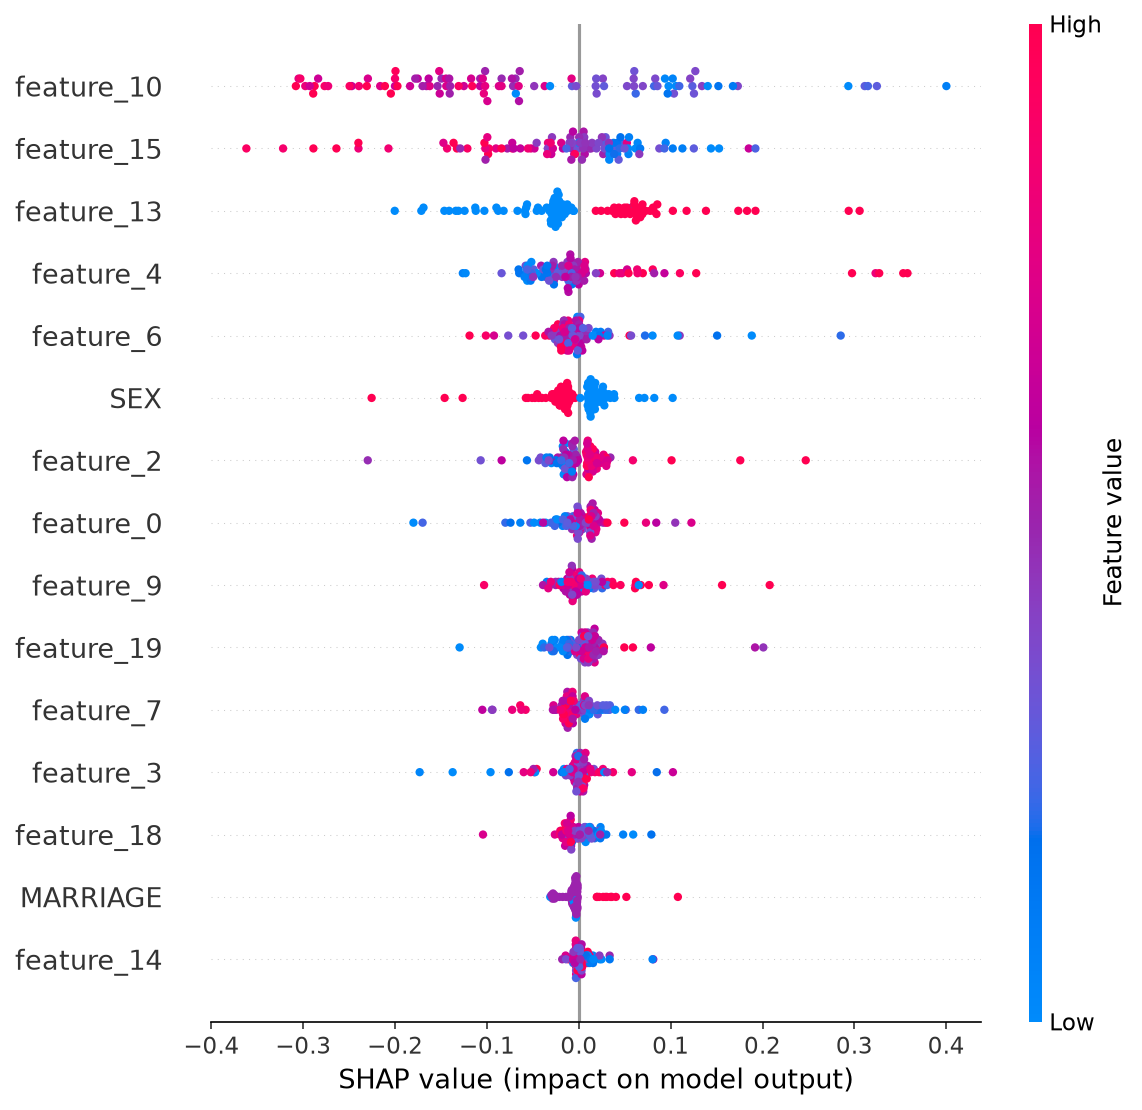

In [3]:
n_explain = min(ip.DEFAULT_N_EXPLAIN, fitted["X_test_t"].shape[0])

shap_values, base_value = ip.compute_shap_values(
    best_model, model_step, fitted["X_train_t"], fitted["X_test_t"][:n_explain]
)
agg_values, agg_names = ip.aggregate_onehot_shap(shap_values, fitted["feature_names"])
display_matrix = ip.build_aggregated_display_matrix(
    fitted["X_test"].iloc[:n_explain], fitted["X_test_t"][:n_explain], fitted["feature_names"]
)

summary_path = config.FIGURES_DIR / f"shap_summary_{best_model}.png"
ip.plot_shap_summary(agg_values, display_matrix, agg_names, save_path=str(summary_path))

from IPython.display import Image, display as ipy_display

ipy_display(Image(filename=str(summary_path)))

## SHAP local: una observación bien clasificada y una con error alto

{'well_classified': 0, 'high_error': 32}
well_classified: y_true=0, y_pred=0, proba=0.000


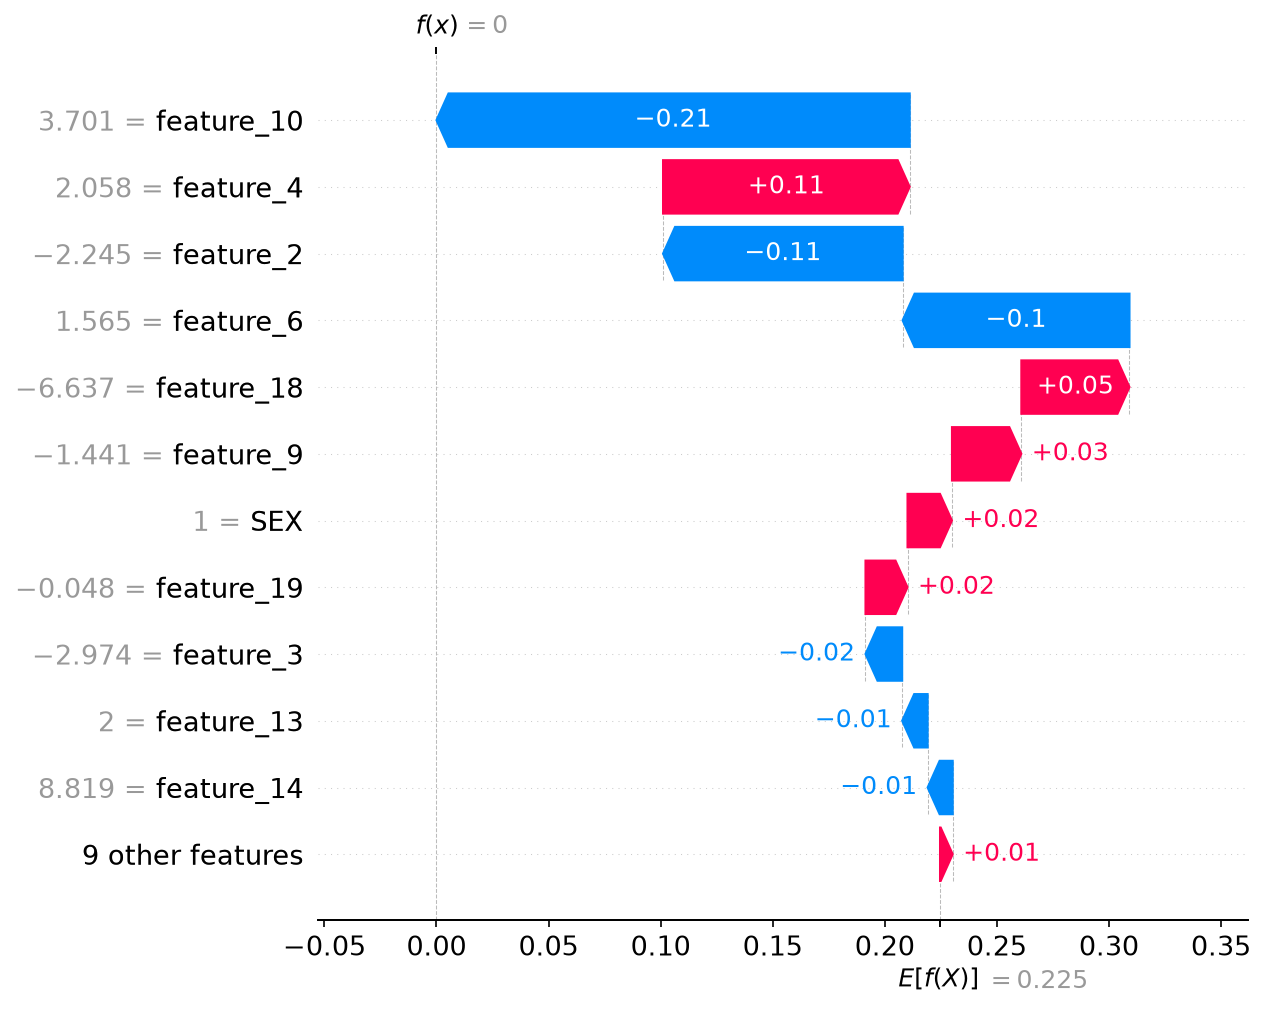

high_error: y_true=1, y_pred=0, proba=0.000


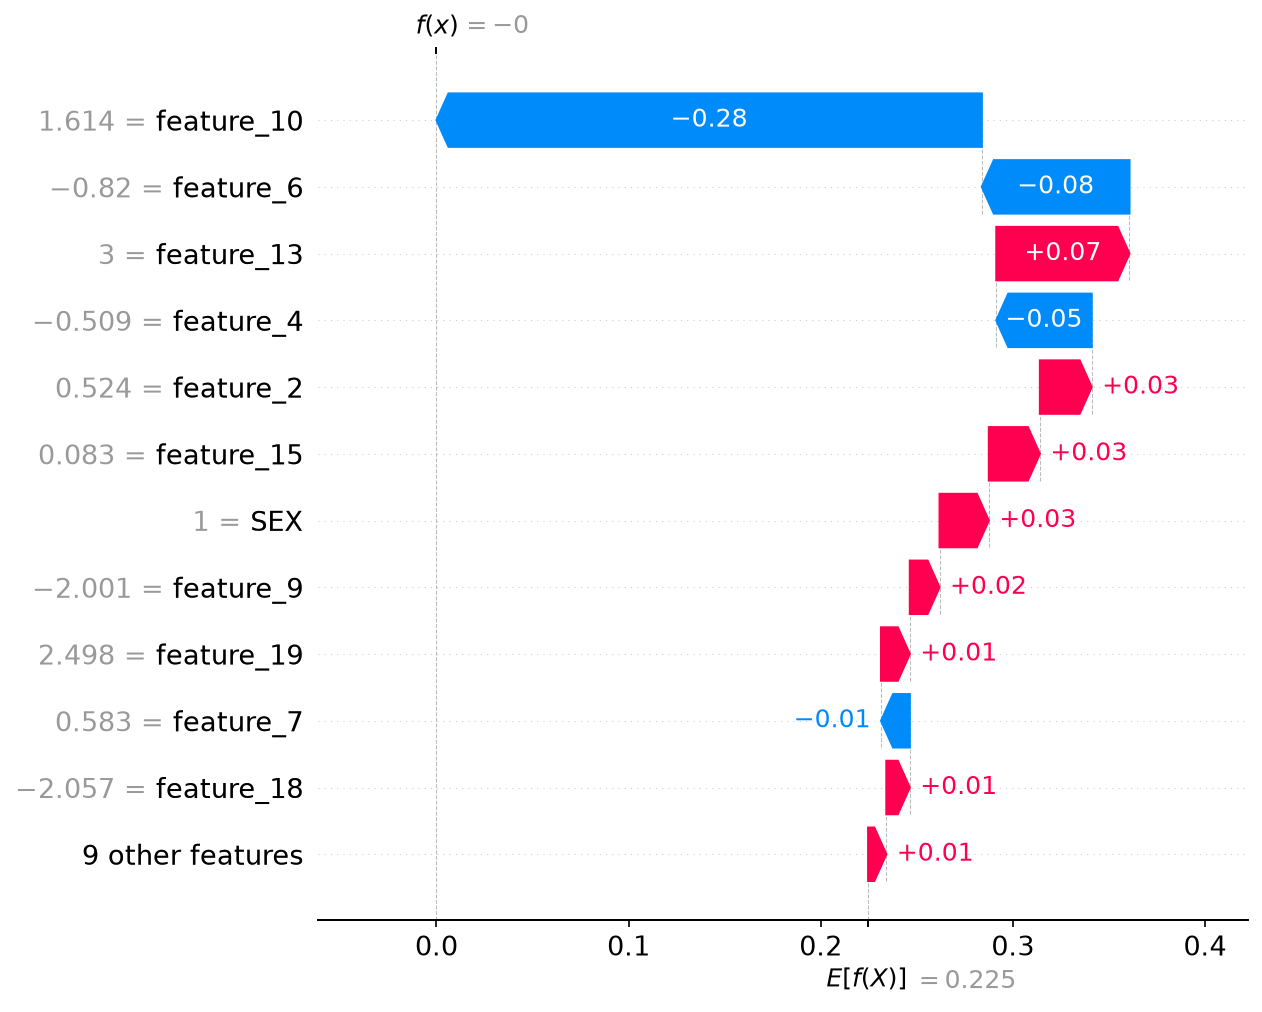

In [4]:
y_pred_test = fitted["pipeline"].predict(fitted["X_test"])
y_proba_test = fitted["pipeline"].predict_proba(fitted["X_test"])[:, 1]
instances = ip.select_representative_instances(fitted["y_test"].to_numpy(), y_pred_test, y_proba_test)
print(instances)

for label, pos in instances.items():
    x_row_t = fitted["X_test_t"][pos : pos + 1]
    sv, bv = ip.compute_shap_values(best_model, model_step, fitted["X_train_t"], x_row_t)
    agg_sv, agg_n = ip.aggregate_onehot_shap(sv, fitted["feature_names"])
    row_display = ip.build_aggregated_display_matrix(
        fitted["X_test"].iloc[pos : pos + 1], x_row_t, fitted["feature_names"]
    )
    waterfall_path = config.FIGURES_DIR / f"shap_waterfall_{best_model}_{label}.png"
    ip.plot_shap_waterfall(agg_sv[0], bv, row_display[0], agg_n, save_path=str(waterfall_path))
    print(
        f"{label}: y_true={fitted['y_test'].iloc[pos]}, y_pred={y_pred_test[pos]}, "
        f"proba={y_proba_test[pos]:.3f}"
    )
    ipy_display(Image(filename=str(waterfall_path)))

## LIME vs. SHAP (específicamente para XGBoost)

Si el mejor modelo ya es XGBoost, esta sección reutiliza el mismo ajuste de arriba; si no, ajusta la mejor combinación de XGBoost por separado (el curso pide esta comparación puntualmente para XGBoost, más allá de cuál haya resultado ser el mejor modelo global).

In [5]:
xgb_rows = table[table["model"] == "xgboost"]

if xgb_rows.empty:
    print(
        "No hay corridas de XGBoost en la tabla maestra todavía: "
        "correr 04_run_experiments.ipynb incluyendo xgboost para esta sección."
    )
else:
    xgb_best_row = xgb_rows.sort_values(f"{metric_for_ranking}_mean", ascending=False).iloc[0]
    xgb_technique = xgb_best_row["technique"]
    xgb_best_params_per_fold = json.loads(xgb_best_row["best_params_per_fold"])
    xgb_per_fold_metric = json.loads(xgb_best_row[f"{metric_for_ranking}_per_fold"])
    xgb_fold_idx = int(np.argmax(xgb_per_fold_metric))
    xgb_best_params = xgb_best_params_per_fold[xgb_fold_idx]

    xgb_spec = MODEL_REGISTRY["xgboost"]
    xgb_fitted = ip.fit_explainable_pipeline(
        xgb_spec, xgb_technique, xgb_best_params, X, y, xgb_fold_idx,
        n_outer_folds=int(xgb_best_row["n_outer_folds"]),
    )
    xgb_model_step = xgb_fitted["pipeline"].named_steps["model"]

    xgb_y_pred = xgb_fitted["pipeline"].predict(xgb_fitted["X_test"])
    xgb_y_proba = xgb_fitted["pipeline"].predict_proba(xgb_fitted["X_test"])[:, 1]
    xgb_instances = ip.select_representative_instances(
        xgb_fitted["y_test"].to_numpy(), xgb_y_pred, xgb_y_proba
    )

    pos = xgb_instances["high_error"]
    x_row_t = xgb_fitted["X_test_t"][pos : pos + 1]

    lime_exp = ip.explain_with_lime(
        xgb_model_step, xgb_fitted["X_train_t"], xgb_fitted["feature_names"], x_row_t
    )
    sv, bv = ip.compute_shap_values("xgboost", xgb_model_step, xgb_fitted["X_train_t"], x_row_t)
    comparison_table = ip.compare_shap_lime(sv[0], lime_exp, xgb_fitted["feature_names"])

    print(f"Observación 'high_error' (XGBoost, {xgb_technique}, fold {xgb_fold_idx}):")
    display(comparison_table)

No hay corridas de XGBoost en la tabla maestra todavía: correr 04_run_experiments.ipynb incluyendo xgboost para esta sección.


### Discusión: ¿cuándo divergen LIME y SHAP?

- **LIME** ajusta un modelo sustituto LINEAL (regularizado) sobre muestras perturbadas alrededor de la observación, ponderadas por cercanía: una aproximación local cuya validez depende del ancho del kernel y el número de muestras perturbadas.
- **SHAP** calcula valores de Shapley (teoría de juegos cooperativos): el aporte marginal promedio de cada feature sobre todas las coaliciones posibles. Para árboles, `TreeExplainer` los calcula de forma EXACTA, y satisface axiomas de consistencia que LIME no garantiza.

**Divergen quando:**
1. **Features correlacionadas** (ej. el bloque `BILL_AMT1`-`BILL_AMT6`, VIF alto según el EDA): SHAP reparte el crédito entre ellas; LIME (Lasso) puede anular una y sobre-atribuir a la otra.
2. **No linealidad local fuerte** (ej. el efecto no lineal de `PAY_0` que el EDA ya detectó): un sustituto lineal como el de LIME la aproxima mal; SHAP (exacto para árboles) la sigue reflejando correctamente.
3. **Sensibilidad a hiperparámetros de LIME** (ancho del kernel, nº de muestras): puede cambiar el ranking entre corridas; SHAP/TreeExplainer es determinístico.

(Texto completo en `interpretability.DISCUSSION_LIME_VS_SHAP`.)